<a href="https://colab.research.google.com/github/syanyong/SQL_Fundamental_SCGP_Hands_on/blob/main/SQL_Fundamental_SCGP_Hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SQL Fundamental — Hands-on Notebook (SCGP)

**เรียนรู้ SQL ด้วยการลงมือปฏิบัติจริงบน Google Colab — เหมาะสำหรับผู้ที่ไม่เคยเขียนโค้ดมาก่อน**

> **SQL** ย่อมาจาก **Structured Query Language** (ภาษาสอบถามข้อมูลเชิงโครงสร้าง) เป็นภาษามาตรฐานสำหรับสอบถามและจัดการข้อมูลในฐานข้อมูล

# 📘 Chapter 1 — เริ่มต้นที่นี่ (สำหรับผู้ที่ไม่เคยเขียนโค้ด)

**Google Colab คืออะไร?** เว็บแอปพลิเคชันที่ให้ท่านรันโค้ดได้ในเบราว์เซอร์ โดยไม่ต้องติดตั้งโปรแกรมใด ๆ ในเครื่อง

- ทำงานบนคลาวด์ของ Google — เพียงมีบัญชี Google และเบราว์เซอร์
- โค้ดถูกแบ่งเป็น **กล่องคำสั่ง (cell)** กดปุ่ม ▶️ ทางซ้ายของกล่องเพื่อรันทีละกล่อง
- ในหลักสูตรนี้ท่านจะใช้ **SQL** (Structured Query Language) เพื่อสอบถามข้อมูลจากฐานข้อมูล มิใช่การเขียนโปรแกรมเพื่อสร้างระบบ

> ทำตามลำดับจากบนลงล่าง กดรันทีละกล่อง หากติดขัดสามารถรันกล่องนั้นซ้ำได้

---
# 🔧 Chapter 2 — เตรียมความพร้อม (ดำเนินการครั้งเดียวเมื่อเริ่มต้น)

ขั้นตอนนี้มีกล่องคำสั่ง 3 กล่อง กรุณากดรันทีละกล่องตามลำดับ

> **การเชื่อมต่อ Google Drive:** ก่อนเริ่ม กรุณา **อัปโหลดไฟล์ `db_training_jul.db` ขึ้น Google Drive** ของท่าน (วางไว้ที่ *My Drive* ชั้นบนสุดได้) จากนั้นรันกล่องด้านล่างเพื่อเชื่อมต่อ Drive

**กล่องที่ 1 — เชื่อมต่อ Drive และระบุตำแหน่งไฟล์ฐานข้อมูล `db_training_jul.db`**

1. อัปโหลด `db_training_jul.db` ขึ้น Google Drive ก่อน (เช่น *My Drive*)
2. รันกล่องเชื่อมต่อ Drive แล้วปรับค่า `DB_PATH` ให้ตรงกับตำแหน่งไฟล์
3. เมื่อรันสำเร็จจะแสดงข้อความ `พบไฟล์ฐานข้อมูล ✅`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DB_PATH = '/content/drive/MyDrive/db_training_jul.db'

if os.path.exists(DB_PATH):
    print('พบไฟล์ฐานข้อมูล ✅', DB_PATH)
else:
    print('❌ ไม่พบไฟล์ที่', DB_PATH, '— โปรดตรวจ path อีกครั้ง')

พบไฟล์ฐานข้อมูล ✅ /content/drive/MyDrive/db_training_jul.db


**กล่องที่ 2 — ติดตั้งเครื่องมือที่จำเป็น**

เครื่องมือ `ipython-sql` ช่วยให้ท่านพิมพ์คำสั่ง SQL ในกล่องคำสั่งได้โดยตรง และแสดงผลลัพธ์เป็นตารางที่อ่านง่าย

In [ ]:
%pip install -q ipython-sql "prettytable==2.5.0" pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.4 MB/s eta 0:00:00


**กล่องที่ 3 — เปิดใช้งานและเชื่อมต่อฐานข้อมูล**

เมื่อรันสำเร็จจะแสดงเครื่องหมาย ✅ หมายความว่าพร้อมเขียนคำสั่ง SQL แล้ว

In [ ]:
%load_ext sql
# สร้าง connection string จาก DB_PATH (ใช้ absolute path กันหาไฟล์ไม่เจอ)
abs_db = os.path.abspath(DB_PATH)
conn_str = f'sqlite:///{abs_db}'
%sql $conn_str
print('เชื่อมฐานข้อมูลแล้ว:', abs_db)
print('พร้อมใช้งาน ✅ — ต่อจากนี้เขียน SQL ในกล่องที่ขึ้นต้นด้วย %%sql ได้เลย')

เชื่อมฐานข้อมูลแล้ว: /content/drive/MyDrive/db_training_jul.db
พร้อมใช้งาน ✅ — ต่อจากนี้เขียน SQL ในกล่องที่ขึ้นต้นด้วย %%sql ได้เลย


**รูปแบบการเขียน SQL ต่อจากนี้:** กล่องคำสั่งที่ต้องรัน SQL จะขึ้นต้นด้วย `%%sql` ในบรรทัดแรกเสมอ ตามด้วยคำสั่ง SQL เช่น

```sql
%%sql
SELECT * FROM Customers;
```

In [ ]:
%%sql
SELECT name FROM sqlite_master WHERE type='table';

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


name
Returns
Customers
Orders
Shipments


เมื่อได้ผลลัพธ์เป็นตารางแล้ว แสดงว่าการเตรียมความพร้อมสมบูรณ์ พร้อมเริ่มบทเรียนถัดไป

---
# 🎯 Chapter 3 — บทนำ: เหตุผลที่ควรเรียนรู้ SQL

หลักสูตรนี้ไม่ได้มุ่งให้ท่าน “เรียนภาษา SQL” เป็นหลัก แต่มุ่งให้ท่าน **สอบถามข้อมูลเพื่อหาคำตอบทางธุรกิจ** ได้ โดยไม่ต้องไล่ดูข้อมูลใน Excel ทีละแถว

คำถามทางธุรกิจที่ SQL ช่วยตอบได้ เช่น

- วันนี้สินค้าใดขายดีที่สุด
- ภูมิภาคใดมียอดขายลดลง
- ลูกค้ารายใดมียอดซื้อสูงสุด
- สินค้าใดขายดีแต่มีอัตรากำไรต่ำ
- มีรายการสั่งซื้อใดที่ผิดปกติหรือไม่
- ฝ่ายขายและฝ่ายผลิตจะใช้ข้อมูลชุดเดียวกันได้อย่างไร

### 3.1 เริ่มจากปัญหาที่พบในการทำงานด้วย Excel

สมมติว่าท่านมีไฟล์ยอดขายจำนวน 5,000–20,000 แถว และผู้บริหารถามว่า:

> **“สินค้าแต่ละชนิดมียอดขายรวมเท่าไร?”**

ใน Excel ท่านอาจต้องใช้ PivotTable หรือสูตร SUMIF ร่วมกัน และใช้เวลาพอสมควร

ด้วย SQL ท่านเพียงเขียนคำสั่งสั้น ๆ เพื่อให้ฐานข้อมูลตอบคำถามนั้น ลองรันกล่องด้านล่าง:

**โจทย์ทางธุรกิจ:** สินค้าแต่ละชนิดมียอดขายรวมเท่าไร (บาท)?

In [ ]:
%%sql
SELECT Product, SUM(Unit_Price * Quantity) AS Total_Sales
FROM Orders
GROUP BY Product
ORDER BY Total_Sales DESC;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Product,Total_Sales
Box,1219.2002999999995
Tape,1102.3003999999996
Paper,1077.3979999999995
Carton,1017.0970000000003


ผลลัพธ์ข้างต้นแสดงยอดขายรวม (บาท) ของสินค้าแต่ละชนิด เรียงจากมากไปน้อย ด้วยคำสั่งเพียงไม่กี่บรรทัด

การเขียน SQL ในลักษณะนี้คือ *การตั้งคำถามให้ฐานข้อมูลตอบ* มิใช่การเขียนโปรแกรมเพื่อสร้างระบบ

### 3.2 ความสัมพันธ์ระหว่าง Excel และ SQL

Excel และ SQL เหมาะกับงานที่แตกต่างกัน และสามารถใช้ร่วมกันได้ ทักษะ Excel ที่ท่านมีอยู่จะช่วยให้เข้าใจแนวคิดของ SQL ได้เร็วขึ้น ดังตารางเทียบเคียงต่อไปนี้

| แนวคิดใน Excel | แนวคิดใน SQL |
|---|---|
| เปิด Sheet | เลือก Table |
| เลือก Column | `SELECT` |
| Filter | `WHERE` |
| Sort | `ORDER BY` |
| PivotTable | `GROUP BY` |
| สูตร SUM, AVG | `SUM()`, `AVG()` |
| VLOOKUP / XLOOKUP | `JOIN` |
| IF | `CASE` |
| หลาย Sheet | หลาย Table |
| รวมข้อมูลหลายชุด | `UNION` |

SQL ไม่ได้มาแทนที่ Excel แต่ช่วยเตรียมข้อมูลที่ถูกต้องและพร้อมใช้ ส่งต่อให้ Excel, Power BI หรือ Dashboard นำไปใช้งานต่อได้ ผู้ที่คุ้นเคยกับ Excel จึงถือว่าเป็นการต่อยอดทักษะเดิม

ตลอดหลักสูตรนี้จะนำเสนอเนื้อหาในรูปแบบ **โจทย์ทางธุรกิจ** ก่อน แล้วจึงแสดงคำสั่ง SQL ที่ใช้ตอบโจทย์นั้น

---
# 🗂️ Chapter 4 — โครงสร้างตาราง (Schema) ที่ใช้ในการอบรมครั้งนี้

ก่อนเริ่มเขียนคำสั่ง SQL กรุณาศึกษาว่าแต่ละตารางประกอบด้วยคอลัมน์ใดบ้าง · 🔑 หมายถึงคีย์หลัก (Primary Key) ซึ่งมีค่าไม่ซ้ำ ใช้อ้างอิงแต่ละแถว

**ตาราง `Customers` — ข้อมูลลูกค้า**

| คอลัมน์ | ชนิด | คำอธิบาย |
|---|---|---|
| 🔑 `Customer_ID` | INTEGER | รหัสลูกค้า (ไม่ซ้ำ) |
| `Customer_Name` | TEXT | ชื่อลูกค้า เช่น บริษัท สมชายพาณิชย์ จำกัด, หจก. ใจดีการค้า |
| `Province` | TEXT | จังหวัด เช่น กรุงเทพมหานคร, เชียงใหม่, สงขลา |
| `Region` | TEXT | ภาค เช่น Central, North, South |

**ตาราง `Orders` — ข้อมูลออเดอร์**

| คอลัมน์ | ชนิด | คำอธิบาย |
|---|---|---|
| 🔑 `Order_ID` | INTEGER | รหัสออเดอร์ (ไม่ซ้ำ, เริ่มที่ 1001) |
| 🔗 `Customer_ID` | INTEGER | ลูกค้าที่สั่ง → เชื่อมกับ `Customers.Customer_ID` |
| `Product` | TEXT | ชนิดสินค้า เช่น Box, Paper, Carton, Tape |
| `Unit_Price` | REAL | ราคาต่อชิ้น (หน่วย: บาท) |
| `Quantity` | INTEGER | จำนวนที่สั่ง (ชิ้น) |
| `Order_Datetime` | DATETIME | วันและเวลาที่สั่ง เช่น `2026-06-01 07:10:00` |

> 💡 ยอดเงินรวมของแต่ละออเดอร์ = `Unit_Price × Quantity` (คำนวณเองในคิวรี ไม่มีคอลัมน์สำเร็จรูป)

**ตาราง `Returns` — ข้อมูลการคืนสินค้า**

| คอลัมน์ | ชนิด | คำอธิบาย |
|---|---|---|
| 🔑 `Return_ID` | INTEGER | รหัสการคืน (ไม่ซ้ำ) |
| 🔗 `Order_ID` | INTEGER | ออเดอร์ที่ถูกคืน → เชื่อมกับ `Orders.Order_ID` |
| `Reason` | TEXT | เหตุผล เช่น Damaged, Wrong Item, Late Delivery |
| `Severity` | TEXT | ความรุนแรง: Low / Medium / High |

**ความสัมพันธ์ระหว่างตาราง (ใช้ตอน JOIN):**

```
Customers ──< Orders ──< Returns
```
- ลูกค้า 1 ราย มีได้หลายออเดอร์ → เชื่อมผ่าน `Customer_ID`
- ออเดอร์ 1 รายการ อาจถูกคืน → เชื่อมผ่าน `Order_ID`

---
# 📊 Chapter 5 — การดึงข้อมูลพื้นฐาน (SELECT · WHERE · ORDER BY)

เริ่มจากการสอบถามข้อมูลออกมาแสดง คำสั่งหลักคือ `SELECT ... FROM ...`

### 5.1 ดึงข้อมูลทั้งหมดด้วย `SELECT * FROM Customers;`

**โจทย์ทางธุรกิจ:** ต้องการดูข้อมูลลูกค้าทั้งหมดในฐานข้อมูล

- `SELECT *` = เลือก **ทุกคอลัมน์** (เครื่องหมาย `*` หมายถึงทั้งหมด)
- `FROM Customers` = จากตารางลูกค้า

คำสั่งนี้เหมาะสำหรับการสำรวจเบื้องต้นว่าตารางมีข้อมูลใดบ้าง

In [ ]:
%%sql
SELECT * FROM Customers;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_ID,Customer_Name,Province,Region
1,บริษัท สมชายพาณิชย์ จำกัด,กรุงเทพมหานคร,Central
2,หจก. ใจดีการค้า,นนทบุรี,Central
3,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,เชียงใหม่,North
4,หจก. ธนกรวัสดุภัณฑ์,พิษณุโลก,North
5,บริษัท ไพศาลกล่องกระดาษ จำกัด,สงขลา,South
6,หจก. มานะเทรดดิ้ง,ภูเก็ต,South


### 5.2 จำกัดจำนวนแถวด้วย `LIMIT`

**โจทย์ทางธุรกิจ:** ตาราง `Orders` มีข้อมูลจำนวนมาก ต้องการดูเพียง 10 แถวแรกเพื่อสำรวจ

`LIMIT 10` = แสดงผลเพียง 10 แถวแรก ช่วยให้ผลลัพธ์ไม่ยาวเกินไป (เราจะใช้ `LIMIT` นี้บ่อยตลอดหลักสูตร)

In [ ]:
%%sql
SELECT * FROM Orders LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1001,1,Box,2.1667,3,2026-06-01 07:10:00
1002,2,Paper,3.0,2,2026-06-01 09:30:00
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1006,1,Box,1.45,4,2026-06-02 06:40:00
1007,2,Paper,1.8667,3,2026-06-02 08:15:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1009,4,Tape,1.3,3,2026-06-02 13:25:00
1010,2,Box,0.625,8,2026-06-02 18:40:00


### 5.3 เลือกเฉพาะคอลัมน์ที่ต้องการ

**โจทย์ทางธุรกิจ:** รายงานฝ่ายขายต้องการเห็นเฉพาะเลขที่ออเดอร์และชื่อสินค้า

ไม่จำเป็นต้องเลือกทุกคอลัมน์ สามารถระบุชื่อคอลัมน์ที่ต้องการโดยคั่นด้วยจุลภาค เพื่อให้ผลลัพธ์อ่านง่ายขึ้น

In [ ]:
%%sql
SELECT Order_ID, Product FROM Orders LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Product
1001,Box
1002,Paper
1003,Box
1004,Carton
1005,Box
1006,Box
1007,Paper
1008,Box
1009,Tape
1010,Box


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงเฉพาะคอลัมน์ `Customer_Name` และ `Province` จากตาราง `Customers`

*คำใบ้: เลือกคอลัมน์ที่ต้องการ คั่นด้วยจุลภาค*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 5.4 เปลี่ยนชื่อหัวคอลัมน์ด้วย `AS`

**โจทย์ทางธุรกิจ:** ต้องการแสดงราคาต่อหน่วยโดยใช้หัวคอลัมน์ว่า Price ในรายงาน

`AS` เปลี่ยนเฉพาะ*ชื่อหัวคอลัมน์*ในผลลัพธ์ให้อ่านง่าย โดยไม่กระทบข้อมูลจริงในฐานข้อมูล

In [ ]:
%%sql
SELECT Unit_Price AS Price FROM Orders LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Price
2.1667
3.0
1.0333
0.58
1.22
1.45
1.8667
0.55
1.3
0.625


### 5.5 การคำนวณค่าใหม่ในคิวรี (Unit_Price × Quantity)

**โจทย์ทางธุรกิจ:** ต้องการคำนวณยอดขาย (บาท) ของแต่ละออเดอร์จากราคาต่อหน่วยและจำนวน

สามารถคำนวณคอลัมน์ใหม่ได้ในคิวรี — `Unit_Price * Quantity` คือยอดขายรวมของออเดอร์นั้น

In [ ]:
%%sql
SELECT Order_ID, Product, Unit_Price, Quantity,
       Unit_Price * Quantity AS Amount
FROM Orders
LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Product,Unit_Price,Quantity,Amount
1001,Box,2.1667,3,6.5001
1002,Paper,3.0,2,6.0
1003,Box,1.0333,6,6.199800000000001
1004,Carton,0.58,5,2.9
1005,Box,1.22,5,6.1
1006,Box,1.45,4,5.8
1007,Paper,1.8667,3,5.6001
1008,Box,0.55,10,5.5
1009,Tape,1.3,3,3.9000000000000004
1010,Box,0.625,8,5.0


### 5.6 การกรองข้อมูลด้วย `WHERE`

**โจทย์ทางธุรกิจ:** ต้องการดูเฉพาะรายการสั่งซื้อสินค้าประเภท Box

`WHERE` คือเงื่อนไขคัดกรอง เลือกเฉพาะแถวที่ตรงตามเงื่อนไข (ค่าที่เป็นข้อความต้องอยู่ในเครื่องหมาย `' '`)

In [ ]:
%%sql
SELECT * FROM Orders WHERE Product = 'Box' LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1001,1,Box,2.1667,3,2026-06-01 07:10:00
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1006,1,Box,1.45,4,2026-06-02 06:40:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1010,2,Box,0.625,8,2026-06-02 18:40:00
1011,4,Box,2.95,2,2026-06-03 07:05:00
1014,5,Box,1.26,5,2026-06-03 16:30:00
1015,3,Box,0.98,5,2026-06-03 23:15:00
1016,4,Box,0.48,10,2026-06-04 06:20:00


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงทุกคอลัมน์ของออเดอร์ เฉพาะสินค้า `Paper` (แสดง 10 แถวแรก)

*คำใบ้: ใช้ `WHERE Product = 'Paper'`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

[link text](https://)### 5.7 การค้นหาข้อความบางส่วนด้วย `LIKE`

**โจทย์ทางธุรกิจ:** ต้องการค้นหาสินค้าที่มีตัวอักษร a อยู่ในชื่อ

`LIKE` ใช้ค้นหาข้อความแบบไม่ต้องตรงทั้งหมด โดย `%` แทนตัวอักษรกี่ตัวก็ได้
- `'%a%'` = มีตัว a อยู่ที่ใดก็ได้
- `'B%'` = ขึ้นต้นด้วย B
- `'%r'` = ลงท้ายด้วย r

In [ ]:
%%sql
SELECT * FROM Orders WHERE Product LIKE '%a%' LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1002,2,Paper,3.0,2,2026-06-01 09:30:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1007,2,Paper,1.8667,3,2026-06-02 08:15:00
1009,4,Tape,1.3,3,2026-06-02 13:25:00
1012,2,Paper,2.6,2,2026-06-03 09:55:00
1013,1,Paper,1.6667,3,2026-06-03 12:10:00
1017,1,Paper,1.85,2,2026-06-04 08:40:00
1018,5,Paper,0.41,10,2026-06-04 11:30:00
1020,1,Carton,0.3,10,2026-06-04 19:00:00
1021,3,Paper,0.525,8,2026-06-05 07:50:00


#### 📝 แบบฝึกหัด

**โจทย์:** ค้นหาสินค้าที่ **ชื่อขึ้นต้นด้วยตัว B** และอีกกล่องหนึ่งค้นหาสินค้าที่ **ชื่อลงท้ายด้วยตัว r**

*คำใบ้: ขึ้นต้น: `LIKE 'B%'` · ลงท้าย: `LIKE '%r'`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 5.8 ตัวดำเนินการเปรียบเทียบใน `WHERE`

นอกจากการเทียบข้อความแล้ว เงื่อนไขใน `WHERE` ยังใช้ตัวดำเนินการเปรียบเทียบต่อไปนี้ได้ (มักใช้กับตัวเลข):

| ตัวดำเนินการ | ความหมาย |
|---|---|
| `=` | เท่ากับ |
| `<>` หรือ `!=` | ไม่เท่ากับ |
| `>` `>=` | มากกว่า / มากกว่าหรือเท่ากับ |
| `<` `<=` | น้อยกว่า / น้อยกว่าหรือเท่ากับ |

### 5.9 การกรองด้วยค่าตัวเลข (`>=`)

**โจทย์ทางธุรกิจ:** ต้องการดูออเดอร์ที่มีราคาต่อหน่วยตั้งแต่ 200,000 บาทขึ้นไป

ค่าที่เป็นตัวเลขไม่ต้องใส่เครื่องหมายคำพูด

In [ ]:
%%sql
SELECT * FROM Orders WHERE Unit_Price >= 200000 LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime


### 5.10 เงื่อนไขที่ต้องเป็นจริงทั้งหมด (`AND`)

**โจทย์ทางธุรกิจ:** ต้องการดูออเดอร์สินค้า Box ที่มีจำนวนตั้งแต่ 5 ชิ้นขึ้นไป

`AND` = ทุกเงื่อนไขต้องเป็นจริงพร้อมกัน

In [ ]:
%%sql
SELECT * FROM Orders WHERE Product = 'Box' AND Quantity >= 5 LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1010,2,Box,0.625,8,2026-06-02 18:40:00
1014,5,Box,1.26,5,2026-06-03 16:30:00
1015,3,Box,0.98,5,2026-06-03 23:15:00
1016,4,Box,0.48,10,2026-06-04 06:20:00
1019,2,Box,0.54,5,2026-06-04 14:50:00
1029,1,Box,0.7833,6,2026-06-06 17:54:00
1031,1,Box,1.18,5,2026-06-06 19:21:00


### 5.11 เงื่อนไขที่เป็นจริงข้อใดข้อหนึ่ง (`OR`)

**โจทย์ทางธุรกิจ:** ต้องการดูออเดอร์ที่เป็นสินค้า Box หรือ Carton

`OR` = เป็นจริงเพียงข้อใดข้อหนึ่งก็เข้าเงื่อนไข

In [ ]:
%%sql
SELECT * FROM Orders WHERE Product = 'Box' OR Product = 'Carton' LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1001,1,Box,2.1667,3,2026-06-01 07:10:00
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1006,1,Box,1.45,4,2026-06-02 06:40:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1010,2,Box,0.625,8,2026-06-02 18:40:00
1011,4,Box,2.95,2,2026-06-03 07:05:00
1014,5,Box,1.26,5,2026-06-03 16:30:00
1015,3,Box,0.98,5,2026-06-03 23:15:00


### 5.12 การผสม `AND` กับ `OR`

**โจทย์ทางธุรกิจ:** ต้องการดูออเดอร์สินค้า Box หรือ Carton **ที่มีจำนวนตั้งแต่ 5 ชิ้นขึ้นไป**

เมื่อใช้ `AND` และ `OR` ร่วมกัน ควรใส่ **วงเล็บ** ครอบกลุ่มเงื่อนไข `OR` เพื่อกำหนดลำดับการทำงานให้ชัดเจน
- ในวงเล็บ: เป็น Box หรือ Carton
- นอกวงเล็บ: และต้องมีจำนวน ≥ 5

In [ ]:
%%sql
SELECT * FROM Orders
WHERE (Product = 'Box' OR Product = 'Carton')
  AND Quantity >= 5
LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1010,2,Box,0.625,8,2026-06-02 18:40:00
1014,5,Box,1.26,5,2026-06-03 16:30:00
1015,3,Box,0.98,5,2026-06-03 23:15:00
1016,4,Box,0.48,10,2026-06-04 06:20:00
1019,2,Box,0.54,5,2026-06-04 14:50:00
1020,1,Carton,0.3,10,2026-06-04 19:00:00


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงออเดอร์สินค้า Paper หรือ Tape ที่ราคาต่อหน่วยมากกว่า 100,000 บาท

*คำใบ้: ใส่วงเล็บครอบเงื่อนไข `OR` แล้วต่อด้วย `AND`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 5.13 การเรียงลำดับผลลัพธ์ (`ORDER BY`)

**โจทย์ทางธุรกิจ:** ต้องการเรียงออเดอร์ตามจำนวนที่สั่ง

`ORDER BY` เรียงลำดับผลลัพธ์ตามคอลัมน์ที่ระบุ
- `ASC` = จากน้อยไปมาก (ค่าเริ่มต้น หากไม่ระบุจะเรียงแบบนี้)
- `DESC` = จากมากไปน้อย

> 💡 มักใช้ `ORDER BY` ร่วมกับ `LIMIT` เพื่อดูอันดับต้น ๆ เช่น เรียงมากไปน้อยแล้ว `LIMIT 3` จะได้ 3 อันดับแรก

In [ ]:
%%sql
SELECT * FROM Orders ORDER BY Quantity ASC LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1002,2,Paper,3.0,2,2026-06-01 09:30:00
1011,4,Box,2.95,2,2026-06-03 07:05:00
1012,2,Paper,2.6,2,2026-06-03 09:55:00
1017,1,Paper,1.85,2,2026-06-04 08:40:00
1025,3,Tape,3.15,2,2026-06-06 15:16:00
1040,5,Tape,1.35,2,2026-06-07 04:02:00
1051,4,Tape,1.85,2,2026-06-07 12:51:00
1077,2,Tape,2.4,2,2026-06-08 08:48:00
1079,2,Carton,2.55,2,2026-06-08 10:19:00
1105,3,Carton,3.15,2,2026-06-09 07:47:00


เรียงจากมากไปน้อยด้วย `DESC` แล้วใช้ `LIMIT 5` เพื่อดู 5 อันดับแรก:

In [ ]:
%%sql
SELECT * FROM Orders ORDER BY Quantity DESC LIMIT 5;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1008,3,Box,0.55,10,2026-06-02 10:50:00
1016,4,Box,0.48,10,2026-06-04 06:20:00
1018,5,Paper,0.41,10,2026-06-04 11:30:00
1020,1,Carton,0.3,10,2026-06-04 19:00:00
1042,1,Tape,0.62,10,2026-06-07 05:43:00


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงออเดอร์เรียงตามราคาต่อหน่วย (`Unit_Price`) จากมากไปน้อย และแสดงเพียง 5 อันดับแรก

*คำใบ้: ใช้ `ORDER BY ... DESC` ร่วมกับ `LIMIT 5`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 5.14 การกรองข้อมูลตามช่วงเวลา (ด้วย `WHERE`)

**โจทย์ทางธุรกิจ:** ต้องการดูออเดอร์ทั้งหมดที่เกิดขึ้นในวันที่ 1 มิถุนายน 2026

คอลัมน์ `Order_Datetime` เก็บทั้งวันที่และเวลา เราสามารถกรองตามวันที่ได้ด้วย `WHERE` โดยตรง โดยใช้ฟังก์ชัน `DATE()` ดึงเฉพาะส่วนวันที่

> 💡 **เทียบกับ Excel:** การกรองแบบนี้ก็เหมือนการใช้ Filter ตามคอลัมน์วันที่ — แต่ SQL ทำได้ทันทีในบรรทัดเดียว และเมื่อข้อมูลมีเป็นหมื่นแถว SQL จะเร็วกว่ามาก

In [ ]:
%%sql
SELECT * FROM Orders
WHERE DATE(Order_Datetime) = '2026-06-01'
LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1001,1,Box,2.1667,3,2026-06-01 07:10:00
1002,2,Paper,3.0,2,2026-06-01 09:30:00
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1005,4,Box,1.22,5,2026-06-01 22:05:00


กรองช่วงวันที่ด้วย `BETWEEN` ก็ได้ — เอาเฉพาะออเดอร์ระหว่างวันที่ 1–3 มิถุนายน 2026:

In [ ]:
%%sql
SELECT * FROM Orders
WHERE DATE(Order_Datetime) BETWEEN '2026-06-01' AND '2026-06-03'
LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_ID,Product,Unit_Price,Quantity,Order_Datetime
1001,1,Box,2.1667,3,2026-06-01 07:10:00
1002,2,Paper,3.0,2,2026-06-01 09:30:00
1003,1,Box,1.0333,6,2026-06-01 11:45:00
1004,3,Carton,0.58,5,2026-06-01 15:20:00
1005,4,Box,1.22,5,2026-06-01 22:05:00
1006,1,Box,1.45,4,2026-06-02 06:40:00
1007,2,Paper,1.8667,3,2026-06-02 08:15:00
1008,3,Box,0.55,10,2026-06-02 10:50:00
1009,4,Tape,1.3,3,2026-06-02 13:25:00
1010,2,Box,0.625,8,2026-06-02 18:40:00


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงออเดอร์ทั้งหมดที่เกิดขึ้นในวันที่ 5 มิถุนายน 2026

*คำใบ้: ใช้ `WHERE DATE(Order_Datetime) = '2026-06-05'`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

---
# 📈 Chapter 6 — การสรุปผลข้อมูล (Aggregation · GROUP BY · CASE)

บทก่อนหน้าเป็นการดึงแถวข้อมูลออกมาแสดง บทนี้จะเป็นการ *สรุปผล* ข้อมูลหลายแถวให้เหลือค่าที่นำไปใช้ตัดสินใจได้

### 6.1 ฟังก์ชันสรุปผล (Aggregate Functions)

ฟังก์ชันเหล่านี้ยุบข้อมูลหลายแถวให้เหลือค่าเดียว:

- `COUNT()` — นับจำนวนแถว
- `SUM()` — ผลรวม
- `AVG()` — ค่าเฉลี่ย
- `MIN()` — ค่าต่ำสุด
- `MAX()` — ค่าสูงสุด

**โจทย์ทางธุรกิจ:** ทั้งฐานข้อมูลมีออเดอร์กี่รายการ ยอดขายรวมเท่าไร ยอดเฉลี่ย ต่ำสุด และสูงสุดเป็นเท่าไร?

In [ ]:
%%sql
SELECT
    COUNT(Order_ID)                AS Total_Orders,
    SUM(Unit_Price * Quantity)     AS Total_Amount,
    AVG(Unit_Price * Quantity)     AS Avg_Amount,
    MIN(Unit_Price * Quantity)     AS Min_Amount,
    MAX(Unit_Price * Quantity)     AS Max_Amount
FROM Orders;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Total_Orders,Total_Amount,Avg_Amount,Min_Amount,Max_Amount
1000,4415.995700000003,4.415995700000003,2.4997,6.5001


#### 📝 แบบฝึกหัด

**โจทย์:** นับว่าตาราง `Customers` มีลูกค้าทั้งหมดกี่ราย

*คำใบ้: ใช้ `COUNT(Customer_ID)`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 6.2 ใช้ฟังก์ชันสรุปผลร่วมกับ `WHERE`

**โจทย์ทางธุรกิจ:** เฉพาะสินค้า Box มีกี่ออเดอร์ และยอดขายรวมเท่าไร?

ใส่ `WHERE` เพื่อกรองแถวก่อน แล้วจึงสรุปผลเฉพาะแถวที่ผ่านเงื่อนไข

In [ ]:
%%sql
SELECT
    COUNT(Order_ID)             AS Total_Orders,
    SUM(Unit_Price * Quantity)  AS Total_Amount
FROM Orders
WHERE Product = 'Box';

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Total_Orders,Total_Amount
273,1219.2002999999995


#### 📝 แบบฝึกหัด

**โจทย์:** หายอดขายรวมของออเดอร์ที่มีจำนวนตั้งแต่ 5 ชิ้นขึ้นไป

*คำใบ้: ใช้ `SUM(Unit_Price * Quantity)` ร่วมกับ `WHERE Quantity >= 5`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 6.3 `GROUP BY`: การสรุปผลแบบแยกกลุ่ม

จนถึงตอนนี้เราสรุปผลทั้งตารางให้เหลือแถวเดียว หากต้องการสรุปผล *แยกตามแต่ละกลุ่ม* ให้ใช้ `GROUP BY`

**โจทย์ทางธุรกิจ:** สินค้าแต่ละชนิดขายได้รวมเท่าไร?

`GROUP BY Product` จัดกลุ่มตามชนิดสินค้า แล้ว `SUM(...)` รวมยอดของแต่ละกลุ่ม

In [ ]:
%%sql
SELECT Product, SUM(Unit_Price * Quantity) AS Total_Amount
FROM Orders
GROUP BY Product;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Product,Total_Amount
Box,1219.2002999999995
Carton,1017.0970000000003
Paper,1077.3979999999995
Tape,1102.3003999999996


#### 📝 แบบฝึกหัด

**โจทย์:** นับจำนวนออเดอร์ของสินค้าแต่ละชนิด

*คำใบ้: ใช้ `COUNT(Order_ID)` ร่วมกับ `GROUP BY Product`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 6.4 `HAVING`: การกรองหลังจัดกลุ่ม

- `WHERE` กรองแถว **ก่อน** จัดกลุ่ม
- `HAVING` กรองกลุ่ม **หลัง** จัดกลุ่มแล้ว (ใช้กับผลของฟังก์ชันสรุปผล)

**โจทย์ทางธุรกิจ:** สินค้าชนิดใดบ้างที่มียอดขายรวมเกิน 110,000,000 บาท?

สามารถอ้างถึงชื่อที่ตั้งด้วย `AS` (เช่น `Total_Amount`) ใน `HAVING` ได้โดยตรง

In [ ]:
%%sql
SELECT Product, SUM(Unit_Price * Quantity) AS Total_Amount
FROM Orders
GROUP BY Product
HAVING Total_Amount > 110000000;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Product,Total_Amount


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงเฉพาะสินค้าที่มีจำนวนออเดอร์มากกว่า 250 รายการ

*คำใบ้: ตั้งชื่อผลนับด้วย `AS Order_Count` แล้วใช้ `HAVING Order_Count > 250`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 6.5 การจัดหมวดด้วย `CASE WHEN` (เงื่อนไขเดียว)

`CASE WHEN` เทียบได้กับ if/else ในการเขียนโปรแกรม ใช้สร้างคอลัมน์ป้ายกำกับตามเงื่อนไข

**โจทย์ทางธุรกิจ:** ต้องการติดป้ายออเดอร์ว่าเป็น `Large` หากยอดตั้งแต่ 500,000 บาทขึ้นไป ที่เหลือเป็น `Normal`

In [ ]:
%%sql
SELECT Order_ID, Unit_Price * Quantity AS Amount,
    CASE WHEN Unit_Price * Quantity >= 500000 THEN 'Large'
         ELSE 'Normal'
    END AS Size
FROM Orders
LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Amount,Size
1001,6.5001,Normal
1002,6.0,Normal
1003,6.199800000000001,Normal
1004,2.9,Normal
1005,6.1,Normal
1006,5.8,Normal
1007,5.6001,Normal
1008,5.5,Normal
1009,3.9000000000000004,Normal
1010,5.0,Normal


### 6.6 `CASE WHEN` แบบหลายเงื่อนไข

**โจทย์ทางธุรกิจ:** ต้องการแบ่งออเดอร์เป็น 3 ระดับตามยอดขาย: `High` (≥ 500,000), `Medium` (≥ 300,000), และ `Low` (ที่เหลือ)

ใส่ `WHEN` ได้หลายเงื่อนไข โดย SQL จะตรวจจากบนลงล่าง และหยุดที่เงื่อนไขแรกที่เป็นจริง

In [ ]:
%%sql
SELECT Order_ID, Unit_Price * Quantity AS Amount,
    CASE WHEN Unit_Price * Quantity >= 500000 THEN 'High'
         WHEN Unit_Price * Quantity >= 300000 THEN 'Medium'
         ELSE 'Low'
    END AS Level
FROM Orders
LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Amount,Level
1001,6.5001,Low
1002,6.0,Low
1003,6.199800000000001,Low
1004,2.9,Low
1005,6.1,Low
1006,5.8,Low
1007,5.6001,Low
1008,5.5,Low
1009,3.9000000000000004,Low
1010,5.0,Low


#### 📝 แบบฝึกหัด

**โจทย์:** สร้างคอลัมน์ `Bulk` โดยติดป้าย `Yes` หากจำนวน (`Quantity`) ตั้งแต่ 5 ชิ้นขึ้นไป ที่เหลือเป็น `No`

*คำใบ้: ใช้ `CASE WHEN Quantity >= 5 THEN 'Yes' ELSE 'No' END`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 6.7 การสรุปข้อมูลตามช่วงเวลา (จัดเต็มเรื่องวันและเวลา)

ในบทที่ 5 เรากรองข้อมูลตามวันที่ด้วย `WHERE` มาแล้ว เมื่อรวมกับ `GROUP BY` เราจะ *สรุปยอด* ตามช่วงเวลาได้ ซึ่งเป็นความต้องการที่พบบ่อยมากในรายงานธุรกิจ

ฟังก์ชันวันและเวลาของ SQLite ที่ใช้บ่อย:
- `DATE(col)` → `'2026-06-01'` (เฉพาะส่วนวันที่)
- `TIME(col)` → `'07:10:00'` (เฉพาะส่วนเวลา)
- `STRFTIME('%Y-%m', col)` → `'2026-06'` (จัดรูปแบบ เช่น รายเดือน)

**โจทย์ทางธุรกิจ:** แต่ละวันมีออเดอร์กี่รายการ และมียอดขายรวมเท่าไร?

In [ ]:
%%sql
SELECT DATE(Order_Datetime) AS Order_Date,
       COUNT(Order_ID)             AS Total_Orders,
       SUM(Unit_Price * Quantity)  AS Total_Amount
FROM Orders
GROUP BY DATE(Order_Datetime)
ORDER BY Order_Date
LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_Date,Total_Orders,Total_Amount
2026-06-01,5,27.6999
2026-06-02,5,25.8001
2026-06-03,5,27.3001
2026-06-04,5,18.3
2026-06-05,2,7.7
2026-06-06,13,57.299499999999995
2026-06-07,30,137.00029999999998
2026-06-08,29,126.89999999999998
2026-06-09,30,123.2992
2026-06-10,32,134.29930000000002


**โจทย์ทางธุรกิจ:** สรุปยอดขายรายเดือน (รูปแบบ YYYY-MM)

> 💡 **เทียบกับ Excel:** งานแบบนี้ใน Excel ต้องสร้างคอลัมน์ช่วยแยกเดือน แล้วทำ PivotTable — แต่ SQL ทำได้ในคิวรีเดียวด้วย `STRFTIME`

In [ ]:
%%sql
SELECT STRFTIME('%Y-%m', Order_Datetime) AS Month,
       COUNT(Order_ID)             AS Total_Orders,
       SUM(Unit_Price * Quantity)  AS Total_Amount
FROM Orders
GROUP BY Month
ORDER BY Month;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Month,Total_Orders,Total_Amount
2026-06,766,3390.898600000001
2026-07,234,1025.0971000000002


#### 📝 แบบฝึกหัด

**โจทย์:** นับจำนวนออเดอร์ในแต่ละวัน เรียงตามวันที่

*คำใบ้: ใช้ `DATE(Order_Datetime)` ร่วมกับ `GROUP BY`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

---
# 🔗 Chapter 7 — การเชื่อมตาราง (JOIN · UNION · Subquery)

ข้อมูลจริงมักกระจายอยู่หลายตาราง เช่น `Orders` เก็บเพียง `Customer_ID` ส่วนชื่อลูกค้าอยู่ในตาราง `Customers` บทนี้จะเชื่อมตารางเหล่านี้เข้าด้วยกัน

> ในบทนี้เราจะเขียน **ชื่อตารางเต็ม** นำหน้าชื่อคอลัมน์ (เช่น `Orders.Customer_ID`) เพื่อให้เห็นชัดว่าแต่ละคอลัมน์มาจากตารางใด

### 7.1 `INNER JOIN` — เชื่อมเฉพาะแถวที่จับคู่กันได้

`INNER JOIN` แสดงเฉพาะแถวที่จับคู่กันได้ทั้งสองฝั่ง (ถ้าฝั่งใดไม่มีคู่ จะไม่ปรากฏในผลลัพธ์)

> 💡 `INNER JOIN` เขียนย่อเป็น `JOIN` เฉย ๆ ก็ได้ — ผลลัพธ์เหมือนกันทุกประการ

**โจทย์ทางธุรกิจ:** ออเดอร์แต่ละรายการเป็นของลูกค้ารายใด?

เชื่อม `Orders` กับ `Customers` ผ่าน `Customer_ID` ที่ตรงกัน

In [ ]:
%%sql
SELECT Orders.Order_ID, Customers.Customer_Name
FROM Orders
INNER JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID
LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_Name
1001,บริษัท สมชายพาณิชย์ จำกัด
1002,หจก. ใจดีการค้า
1003,บริษัท สมชายพาณิชย์ จำกัด
1004,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด
1005,หจก. ธนกรวัสดุภัณฑ์
1006,บริษัท สมชายพาณิชย์ จำกัด
1007,หจก. ใจดีการค้า
1008,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด
1009,หจก. ธนกรวัสดุภัณฑ์
1010,หจก. ใจดีการค้า


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงเลขที่ออเดอร์ ชื่อสินค้า และชื่อลูกค้า ของออเดอร์ 10 รายการแรก

*คำใบ้: เชื่อม `Orders` กับ `Customers` แล้วเลือก `Orders.Product` กับ `Customers.Customer_Name`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 7.2 `LEFT JOIN` — เก็บทุกแถวจากตารางฝั่งซ้าย

`LEFT JOIN` แสดงทุกแถวจากตารางฝั่งซ้าย แม้ไม่มีคู่ในตารางฝั่งขวา (ฝั่งที่ไม่มีคู่จะแสดงเป็น `NULL`)

**โจทย์ทางธุรกิจ:** ลูกค้ารายใดบ้างที่ยังไม่มีคำสั่งซื้อ?

ใช้ `LEFT JOIN` เพื่อแสดงลูกค้า *ทุกราย* หากรายใดไม่มีออเดอร์ คอลัมน์ `Order_ID` จะเป็น `NULL`

In [ ]:
%%sql
SELECT Customers.Customer_Name, Orders.Order_ID
FROM Customers
LEFT JOIN Orders ON Customers.Customer_ID = Orders.Customer_ID
LIMIT 20;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_Name,Order_ID
บริษัท สมชายพาณิชย์ จำกัด,1001
บริษัท สมชายพาณิชย์ จำกัด,1003
บริษัท สมชายพาณิชย์ จำกัด,1006
บริษัท สมชายพาณิชย์ จำกัด,1013
บริษัท สมชายพาณิชย์ จำกัด,1017
บริษัท สมชายพาณิชย์ จำกัด,1020
บริษัท สมชายพาณิชย์ จำกัด,1029
บริษัท สมชายพาณิชย์ จำกัด,1031
บริษัท สมชายพาณิชย์ จำกัด,1034
บริษัท สมชายพาณิชย์ จำกัด,1038


### 7.3 การเชื่อม 3 ตารางต่อกัน

**โจทย์ทางธุรกิจ:** รายการคืนสินค้าแต่ละรายการ เป็นสินค้าอะไร ของลูกค้ารายใด และด้วยเหตุผลใด?

สามารถต่อ `JOIN` เป็นทอด ๆ ได้: `Returns` → `Orders` → `Customers`

In [ ]:
%%sql
SELECT Returns.Return_ID,
       Orders.Product,
       Customers.Customer_Name,
       Returns.Reason,
       Returns.Severity
FROM Returns
JOIN Orders ON Returns.Order_ID = Orders.Order_ID
JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Return_ID,Product,Customer_Name,Reason,Severity
1,Box,บริษัท สมชายพาณิชย์ จำกัด,Damaged,Low
2,Paper,หจก. ใจดีการค้า,Wrong Item,High
3,Box,หจก. ธนกรวัสดุภัณฑ์,Late Delivery,Medium
4,Paper,หจก. ใจดีการค้า,Quality Issue,Low
5,Tape,หจก. ธนกรวัสดุภัณฑ์,Missing Item,High
6,Paper,หจก. ใจดีการค้า,Wrong Item,Medium
7,Box,บริษัท ไพศาลกล่องกระดาษ จำกัด,Damaged,Low
8,Box,หจก. ธนกรวัสดุภัณฑ์,Late Delivery,High
9,Paper,บริษัท ไพศาลกล่องกระดาษ จำกัด,Quality Issue,Medium
10,Box,หจก. ใจดีการค้า,Missing Item,Low


#### 📝 แบบฝึกหัด

**โจทย์:** แสดงชื่อลูกค้าและเหตุผลการคืน (`Reason`) ของทุกการคืนสินค้า

*คำใบ้: เชื่อม `Returns` → `Orders` → `Customers`*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

### 7.4 `UNION` — การต่อผลลัพธ์ในแนวตั้ง

`JOIN` ต่อตารางในแนวนอน (เพิ่มคอลัมน์) ส่วน `UNION` ต่อในแนวตั้ง (เพิ่มแถว) โดยทั้งสองชุดต้องมีจำนวนคอลัมน์เท่ากัน

**โจทย์ทางธุรกิจ:** ต้องการรวมรายการออเดอร์ Box ของลูกค้ารายที่ 1 เข้ากับออเดอร์ Paper ของลูกค้ารายที่ 2 ไว้ในผลลัพธ์เดียว

In [ ]:
%%sql
SELECT Order_ID, Product FROM Orders WHERE Customer_ID = 1 AND Product = 'Box'
UNION
SELECT Order_ID, Product FROM Orders WHERE Customer_ID = 2 AND Product = 'Paper';

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Product
1001,Box
1002,Paper
1003,Box
1006,Box
1007,Paper
1012,Paper
1029,Box
1031,Box
1034,Box
1038,Box


### 7.5 Subquery — คิวรีซ้อนคิวรี

ในบางกรณีเราต้องใช้ *ผลของคิวรีหนึ่ง* เป็นเงื่อนไขของอีกคิวรีหนึ่ง โดยเขียนคิวรีย่อยไว้ในวงเล็บ

**โจทย์ทางธุรกิจ:** ออเดอร์ใดบ้างที่มียอดขายสูงกว่ายอดเฉลี่ยของทั้งตาราง?

In [ ]:
%%sql
SELECT Order_ID, Unit_Price * Quantity AS Amount
FROM Orders
WHERE Unit_Price * Quantity > (SELECT AVG(Unit_Price * Quantity) FROM Orders)
ORDER BY Amount DESC
LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Amount
1001,6.5001
1828,6.5001
1201,6.5
1241,6.5
1349,6.5
1610,6.5
1659,6.5
1670,6.5
1678,6.5
1751,6.5


### 7.6 การวิเคราะห์ตามช่วงเวลาแบบเชื่อมตาราง (จัดเต็ม)

เมื่อรวม `JOIN` กับฟังก์ชันวันเวลา เราจะวิเคราะห์เหตุการณ์ตามช่วงเวลาข้ามตารางได้

**โจทย์ทางธุรกิจ:** แต่ละวันมีการคืนสินค้ากี่รายการ?

เชื่อม `Orders` กับ `Returns` แล้วจัดกลุ่มตามวัน

In [ ]:
%%sql
SELECT DATE(Orders.Order_Datetime) AS Order_Date,
       COUNT(Returns.Return_ID) AS Total_Returns
FROM Orders
JOIN Returns ON Orders.Order_ID = Returns.Order_ID
GROUP BY DATE(Orders.Order_Datetime)
ORDER BY Order_Date;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_Date,Total_Returns
2026-06-01,3
2026-06-02,3
2026-06-03,2
2026-06-04,4
2026-06-05,2
2026-06-06,3
2026-06-07,4
2026-06-08,6
2026-06-09,2
2026-06-10,1


**โจทย์ทางธุรกิจ:** ในเดือนมิถุนายน 2026 ลูกค้าแต่ละรายมียอดสั่งซื้อรวมเท่าไร?

In [ ]:
%%sql
SELECT Customers.Customer_Name,
       COUNT(Orders.Order_ID)             AS Total_Orders,
       SUM(Orders.Unit_Price * Orders.Quantity) AS Total_Amount
FROM Orders
JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID
WHERE STRFTIME('%Y-%m', Orders.Order_Datetime) = '2026-06'
GROUP BY Customers.Customer_Name
ORDER BY Total_Amount DESC;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_Name,Total_Orders,Total_Amount
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,173,789.0979000000001
หจก. ใจดีการค้า,163,740.9022
หจก. ธนกรวัสดุภัณฑ์,153,650.6987000000001
บริษัท ไพศาลกล่องกระดาษ จำกัด,146,616.6995999999999
บริษัท สมชายพาณิชย์ จำกัด,131,593.5002000000003


#### 📝 แบบฝึกหัด

**โจทย์:** นับจำนวนการคืนสินค้าแยกตามระดับความรุนแรง (`Severity`)

*คำใบ้: ใช้ `COUNT` ร่วมกับ `GROUP BY Returns.Severity` (ไม่ต้อง JOIN ก็ได้)*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

---
# ✏️ Chapter 8 — การสร้างและแก้ไขข้อมูล (CREATE · INSERT · UPDATE · DELETE)

บทก่อนหน้าเป็นการ *อ่าน* ข้อมูล บทนี้จะเป็นการสร้างตารางและปรับปรุงข้อมูล

### 8.1 การสร้างตาราง (`CREATE TABLE`)

**โจทย์ทางธุรกิจ:** ต้องการสร้างตารางใหม่สำหรับเก็บข้อมูลการจัดส่ง

`CREATE TABLE` กำหนดโครงสร้างตาราง ได้แก่ ชื่อคอลัมน์และชนิดข้อมูล (`INTEGER`, `TEXT` ฯลฯ)

In [ ]:
%%sql
DROP TABLE IF EXISTS Shipments;
CREATE TABLE Shipments (
    Shipment_ID INTEGER PRIMARY KEY,
    Order_ID    INTEGER,
    Ship_Date   TEXT,
    Carrier     TEXT,
    Status      TEXT,
    Staff       TEXT
);

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.
Done.


[]

### 8.2 การเพิ่มข้อมูล 1 แถว (`INSERT`)

**โจทย์ทางธุรกิจ:** ต้องการบันทึกรายการจัดส่งใหม่ 1 รายการ

`INSERT INTO ... VALUES (...)` เพิ่มข้อมูล โดยระบุชื่อคอลัมน์แล้วตามด้วยค่าที่ต้องการ

In [ ]:
%%sql
INSERT INTO Shipments
  (Shipment_ID, Order_ID, Ship_Date, Carrier, Status, Staff)
VALUES
  (1, 1001, '2026-06-02', 'Kerry', 'Shipped', 'สมชาย');

 * sqlite:////content/drive/MyDrive/db_training_jul.db
1 rows affected.


[]

### 8.3 การเพิ่มข้อมูลหลายแถวพร้อมกัน

**โจทย์ทางธุรกิจ:** ต้องการบันทึกรายการจัดส่งหลายรายการในคำสั่งเดียว

ใส่หลายแถวในคำสั่งเดียว โดยคั่นแต่ละแถวด้วยจุลภาค

In [ ]:
%%sql
INSERT INTO Shipments
  (Shipment_ID, Order_ID, Ship_Date, Carrier, Status, Staff)
VALUES
  (2, 1003, '2026-06-03', 'Flash', 'Shipped', 'สมหญิง'),
  (3, 1005, '2026-06-04', 'Kerry', 'Pending', 'สมชาย'),
  (4, 1007, '2026-06-05', 'J&T',   'Pending', 'สมศักดิ์');

 * sqlite:////content/drive/MyDrive/db_training_jul.db
3 rows affected.


[]

### 8.4 การตรวจสอบข้อมูลที่เพิ่งเพิ่ม

**โจทย์ทางธุรกิจ:** ตรวจสอบว่าข้อมูลการจัดส่งถูกบันทึกครบทุกรายการ

In [ ]:
%%sql
SELECT * FROM Shipments;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Shipment_ID,Order_ID,Ship_Date,Carrier,Status,Staff
1,1001,2026-06-02,Kerry,Shipped,สมชาย
2,1003,2026-06-03,Flash,Shipped,สมหญิง
3,1005,2026-06-04,Kerry,Pending,สมชาย
4,1007,2026-06-05,J&T,Pending,สมศักดิ์


### 8.5 การแก้ไขข้อมูล (`UPDATE`)

`UPDATE table SET column = ค่าใหม่ WHERE เงื่อนไข`

> ⚠️ **ต้องมี `WHERE` เสมอ** หากลืม จะเป็นการแก้ไขข้อมูลทุกแถวในตาราง

**โจทย์ทางธุรกิจ:** ต้องการเปลี่ยนสถานะการจัดส่งหมายเลข 1 เป็น Delivered

In [ ]:
%%sql
UPDATE Shipments
SET Status = 'Delivered'
WHERE Shipment_ID = 1;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
1 rows affected.


[]

ตรวจสอบผลการอัปเดต:

In [ ]:
%%sql
SELECT * FROM Shipments WHERE Shipment_ID = 1;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Shipment_ID,Order_ID,Ship_Date,Carrier,Status,Staff
1,1001,2026-06-02,Kerry,Delivered,สมชาย


### 8.6 การลบข้อมูล (`DELETE`)

`DELETE FROM table WHERE เงื่อนไข`

> ⚠️ **ต้องมี `WHERE` เสมอ** หากลืม จะเป็นการลบข้อมูลทุกแถวในตาราง

**โจทย์ทางธุรกิจ:** ต้องการลบรายการจัดส่งหมายเลข 2 ออกจากตาราง

In [ ]:
%%sql
DELETE FROM Shipments
WHERE Shipment_ID = 2;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
1 rows affected.


[]

### 8.7 ข้อควรระวัง: ล้างข้อมูล vs ลบตาราง

- `DELETE FROM Shipments;` (ไม่มี WHERE) → ลบ *ทุกแถว* แต่โครงสร้างตารางยังอยู่
- `DROP TABLE Shipments;` → ลบทั้งตารางออกจากฐานข้อมูล

กรุณาใช้คำสั่งทั้งสองด้วยความระมัดระวัง

#### 📝 แบบฝึกหัด

**โจทย์:** เปลี่ยนสถานะของรายการจัดส่งหมายเลข 3 เป็น `Delivered` แล้วตรวจสอบผลด้วย SELECT

*คำใบ้: ใช้ `UPDATE ... SET ... WHERE Shipment_ID = 3` (อย่าลืม `WHERE`)*

In [ ]:
%%sql
-- เขียนคำตอบของท่านต่อจากบรรทัดนี้


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

---
# 🚀 Chapter 9 — การใช้งานขั้นสูง (VIEW · Query รวมทุกแนวคิด)

### 9.1 `VIEW`: การบันทึกคิวรีไว้ใช้ซ้ำ

**โจทย์ทางธุรกิจ:** ต้องการบันทึกคิวรีที่เชื่อมตารางไว้ เพื่อเรียกใช้ซ้ำโดยไม่ต้องเขียน JOIN ใหม่ทุกครั้ง

`VIEW` คือคิวรีที่ตั้งชื่อไว้ เรียกใช้ซ้ำได้เหมือนตารางทั่วไป โดยไม่ได้เก็บข้อมูลซ้ำ

In [ ]:
%%sql
DROP VIEW IF EXISTS v_Orders;
CREATE VIEW v_Orders AS
SELECT
    Orders.Order_ID,
    Customers.Customer_Name,
    Customers.Province,
    Customers.Region,
    Orders.Product,
    Orders.Unit_Price,
    Orders.Quantity,
    Orders.Unit_Price * Orders.Quantity AS Amount,
    Orders.Order_Datetime
FROM Orders
JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.
Done.


[]

เรียกใช้ `v_Orders` ได้เหมือนตารางปกติ โดยไม่ต้องเขียน JOIN ซ้ำ:

In [ ]:
%%sql
SELECT * FROM v_Orders LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Order_ID,Customer_Name,Province,Region,Product,Unit_Price,Quantity,Amount,Order_Datetime
1001,บริษัท สมชายพาณิชย์ จำกัด,กรุงเทพมหานคร,Central,Box,2.1667,3,6.5001,2026-06-01 07:10:00
1002,หจก. ใจดีการค้า,นนทบุรี,Central,Paper,3.0,2,6.0,2026-06-01 09:30:00
1003,บริษัท สมชายพาณิชย์ จำกัด,กรุงเทพมหานคร,Central,Box,1.0333,6,6.199800000000001,2026-06-01 11:45:00
1004,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,เชียงใหม่,North,Carton,0.58,5,2.9,2026-06-01 15:20:00
1005,หจก. ธนกรวัสดุภัณฑ์,พิษณุโลก,North,Box,1.22,5,6.1,2026-06-01 22:05:00
1006,บริษัท สมชายพาณิชย์ จำกัด,กรุงเทพมหานคร,Central,Box,1.45,4,5.8,2026-06-02 06:40:00
1007,หจก. ใจดีการค้า,นนทบุรี,Central,Paper,1.8667,3,5.6001,2026-06-02 08:15:00
1008,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,เชียงใหม่,North,Box,0.55,10,5.5,2026-06-02 10:50:00
1009,หจก. ธนกรวัสดุภัณฑ์,พิษณุโลก,North,Tape,1.3,3,3.9000000000000004,2026-06-02 13:25:00
1010,หจก. ใจดีการค้า,นนทบุรี,Central,Box,0.625,8,5.0,2026-06-02 18:40:00


### 9.2 การผสมคิวรีต่าง ๆ เพื่อแก้โจทย์ทางธุรกิจ 🏆

**โจทย์ทางธุรกิจ:** ลูกค้าแต่ละรายซื้อสินค้าแต่ละชนิดกี่ออเดอร์ และรวมเป็นยอดขายเท่าไร (เรียงจากยอดมากไปน้อย)?

โจทย์นี้ต้องผสมหลายแนวคิดที่เรียนมา: `JOIN` (รวมชื่อลูกค้า) + `GROUP BY` (แยกตามลูกค้าและสินค้า) + `COUNT`/`SUM` (สรุปผล) + `ORDER BY` (เรียงลำดับ)

In [ ]:
%%sql
SELECT Customers.Customer_Name,
       Orders.Product,
       COUNT(Orders.Order_ID)                    AS Total_Orders,
       SUM(Orders.Unit_Price * Orders.Quantity)  AS Total_Amount
FROM Orders
JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID
GROUP BY Customers.Customer_Name, Orders.Product
ORDER BY Total_Amount DESC
LIMIT 15;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_Name,Product,Total_Orders,Total_Amount
หจก. ใจดีการค้า,Box,70,316.90100000000007
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Tape,66,297.49940000000004
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Box,56,259.80000000000007
บริษัท ไพศาลกล่องกระดาษ จำกัด,Paper,60,251.9995000000001
หจก. ธนกรวัสดุภัณฑ์,Box,52,230.3998
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Carton,50,220.19799999999992
หจก. ใจดีการค้า,Carton,50,220.0
หจก. ใจดีการค้า,Tape,46,218.40070000000003
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Paper,49,218.39880000000002
บริษัท ไพศาลกล่องกระดาษ จำกัด,Carton,48,215.50020000000006


### 9.3 เก็บรายงานไว้เป็น `VIEW`

**โจทย์ทางธุรกิจ:** บันทึกรายงานสรุปลูกค้าไว้เป็น View เพื่อเรียกดูได้ทุกเมื่อ

In [ ]:
%%sql
DROP VIEW IF EXISTS v_CustomerReport;
CREATE VIEW v_CustomerReport AS
SELECT Customers.Customer_Name,
       Orders.Product,
       COUNT(Orders.Order_ID)                    AS Total_Orders,
       SUM(Orders.Unit_Price * Orders.Quantity)  AS Total_Amount
FROM Orders
JOIN Customers ON Orders.Customer_ID = Customers.Customer_ID
GROUP BY Customers.Customer_Name, Orders.Product;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.
Done.


[]

เรียก VIEW พร้อมกรองด้วย `WHERE` — ดูเฉพาะรายการที่ยอดรวมเกิน 30,000,000 บาท:

In [ ]:
%%sql
SELECT * FROM v_CustomerReport LIMIT 10;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_Name,Product,Total_Orders,Total_Amount
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Box,56,259.80000000000007
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Carton,50,220.19799999999992
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Paper,49,218.39880000000002
บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,Tape,66,297.49940000000004
บริษัท สมชายพาณิชย์ จำกัด,Box,46,208.1994
บริษัท สมชายพาณิชย์ จำกัด,Carton,37,169.49939999999998
บริษัท สมชายพาณิชย์ จำกัด,Paper,46,206.7
บริษัท สมชายพาณิชย์ จำกัด,Tape,42,193.6009
บริษัท ไพศาลกล่องกระดาษ จำกัด,Box,49,203.9001
บริษัท ไพศาลกล่องกระดาษ จำกัด,Carton,48,215.50020000000006


---
# 📉 Chapter 10 — นำผลคิวรีไปสร้างกราฟ (Plot)

เมื่อเขียนคิวรีสรุปผลได้แล้ว ขั้นต่อไปที่พบบ่อยในงานจริงคือการ *นำผลลัพธ์ไปแสดงเป็นกราฟ* เพื่อสื่อสารกับผู้บริหาร

แนวทางคือ ดึงผลลัพธ์ SQL เข้าสู่ **pandas DataFrame** แล้ววาดกราฟด้วย **matplotlib**

> 💡 **เทียบกับ Excel:** แทนที่จะ copy ข้อมูลไปสร้าง Chart ใน Excel ทีละครั้ง เราสั่งให้คิวรีสรุปผลแล้ววาดกราฟได้ในที่เดียว เมื่อข้อมูลเปลี่ยน เพียงรันซ้ำก็ได้กราฟใหม่ทันที

### 10.1 ดึงผลคิวรีเข้าสู่ DataFrame

เก็บผลลัพธ์ของ `%sql` ไว้ในตัวแปร แล้วแปลงเป็น DataFrame ด้วย `.DataFrame()`

**โจทย์ทางธุรกิจ:** สรุปยอดขายรวมของสินค้าแต่ละชนิด เพื่อเตรียมนำไปวาดกราฟ

In [ ]:
result = %sql SELECT Product, SUM(Unit_Price * Quantity) AS Total_Sales FROM Orders GROUP BY Product ORDER BY Total_Sales DESC
df = result.DataFrame()
df

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


,Product,Total_Sales
0,Box,1219.2003
1,Tape,1102.3004
2,Paper,1077.3980
3,Carton,1017.0970


### 10.2 กราฟแท่ง (Bar Chart) — ยอดขายรายสินค้า

> Add blockquote



**โจทย์ทางธุรกิจ:** สินค้าชนิดใดขายดีที่สุด? แสดงเป็นกราฟแท่งเปรียบเทียบ

ใช้ `df.plot(kind='bar', ...)` วาดกราฟแท่งจาก DataFrame ที่เพิ่งได้

/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2414/3728205872.py:7: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tig

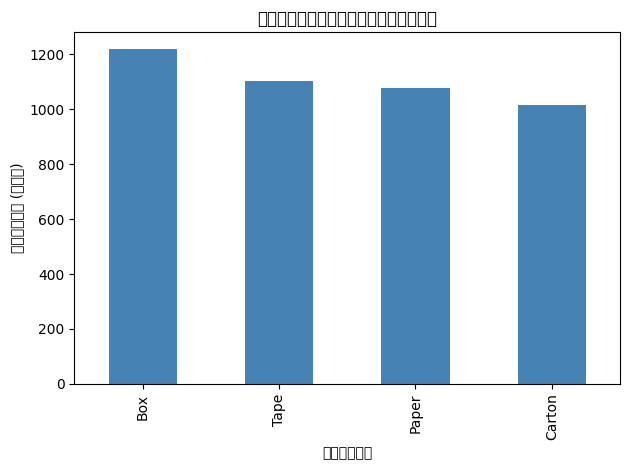

In [ ]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='Product', y='Total_Sales', legend=False, color='steelblue')
plt.title('ยอดขายรวมรายสินค้า')
plt.xlabel('สินค้า')
plt.ylabel('ยอดขาย (บาท)')
plt.tight_layout()
plt.show()

> 📌 หากภาษาไทยบนกราฟแสดงเป็นสี่เหลี่ยม (□) เป็นเพราะยังไม่ได้ตั้งฟอนต์ไทย สามารถเปลี่ยนหัวข้อ/ป้ายกำกับเป็นภาษาอังกฤษก่อนได้ หรือติดตั้งฟอนต์ไทยเพิ่มเติมภายหลัง

### 10.3 กราฟเส้น (Line Chart) — แนวโน้มยอดขายรายวัน

**โจทย์ทางธุรกิจ:** ยอดขายในแต่ละวันมีแนวโน้มอย่างไร? แสดงเป็นกราฟเส้น

กราฟเส้นเหมาะกับข้อมูลตามช่วงเวลา ทำให้เห็นแนวโน้มขึ้น-ลงได้ชัดเจน

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


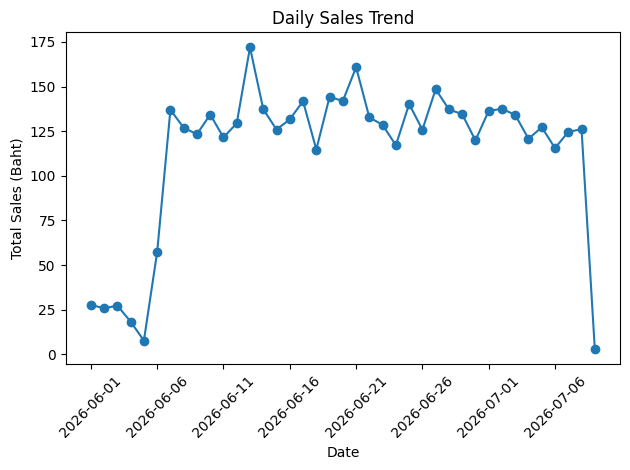

In [ ]:
result2 = %sql SELECT DATE(Order_Datetime) AS Order_Date, SUM(Unit_Price * Quantity) AS Total_Sales FROM Orders GROUP BY Order_Date ORDER BY Order_Date
daily = result2.DataFrame()

daily.plot(kind='line', x='Order_Date', y='Total_Sales', legend=False, marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales (Baht)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 📝 แบบฝึกหัด

**โจทย์:** ดึงยอดขายรวมของลูกค้าแต่ละราย (`Customer_Name`) แล้ววาดเป็นกราฟแท่ง

*คำใบ้: เขียนคิวรี JOIN `Orders` กับ `Customers` เก็บใส่ DataFrame แล้วใช้ `df.plot(kind='bar', ...)`*

In [ ]:
%%sql
-- เขียนคิวรีของท่านที่นี่ก่อน (แล้วเก็บผลใส่ตัวแปรเพื่อนำไป plot ในกล่องถัดไป)


 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


[]

In [ ]:
# นำผลคิวรีด้านบนไป plot ที่นี่


---
## 🎉 จบหลักสูตร SQL Fundamental

ท่านได้เรียนรู้ครบทุกหัวข้อ ตั้งแต่:

1. การดึงข้อมูลพื้นฐาน (SELECT · WHERE · LIKE · ORDER BY · LIMIT · กรองตามเวลา)
2. การสรุปผลข้อมูล (COUNT · SUM · AVG · MIN · MAX · GROUP BY · HAVING · CASE · สรุปตามเวลา)
3. การเชื่อมตาราง (INNER JOIN · LEFT JOIN · UNION · Subquery · วิเคราะห์ตามเวลา)
4. การสร้างและแก้ไขข้อมูล (CREATE · INSERT · UPDATE · DELETE)
5. การใช้งานขั้นสูง (VIEW · การผสมคิวรีเพื่อแก้โจทย์ธุรกิจ)
6. การนำผลคิวรีไปสร้างกราฟด้วย matplotlib

กล่องด้านล่างเป็นพื้นที่ว่างสำหรับทดลองเขียน SQL ด้วยตนเอง

In [ ]:
%%sql
-- ✍️ พื้นที่ทดลองเขียน SQL ของท่าน
SELECT * FROM Customers;

 * sqlite:////content/drive/MyDrive/db_training_jul.db
Done.


Customer_ID,Customer_Name,Province,Region
1,บริษัท สมชายพาณิชย์ จำกัด,กรุงเทพมหานคร,Central
2,หจก. ใจดีการค้า,นนทบุรี,Central
3,บริษัท รุ่งเรืองบรรจุภัณฑ์ จำกัด,เชียงใหม่,North
4,หจก. ธนกรวัสดุภัณฑ์,พิษณุโลก,North
5,บริษัท ไพศาลกล่องกระดาษ จำกัด,สงขลา,South
6,หจก. มานะเทรดดิ้ง,ภูเก็ต,South
